# 🧠 Breast Cancer Classification — Machine Learning Project

## 📌 Project Overview

This project builds a Machine Learning classification system to predict whether a breast tumor is:

- **Malignant**
- **Benign**

The project follows a complete Machine Learning workflow, from data exploration and preprocessing to model training, evaluation, hyperparameter tuning, and final prediction.

## 🎯 Goal

Build and compare multiple Machine Learning classification models and select the best-performing model for predicting tumor diagnosis.

## 🔄 ML Workflow

**Dataset → EDA → Data Cleaning → Outlier Analysis → Feature Engineering → Feature Selection → Train/Test Split → Preprocessing Pipeline → Model Training → Model Comparison → Cross-Validation → Hyperparameter Tuning → Learning Curves → PCA Experiment → Final Model → Evaluation → ROC-AUC → Feature Importance → Probability Prediction → Model Saving → Final Prediction**

## 🤖 Models

- Logistic Regression
- K-Nearest Neighbors (KNN)
- Naive Bayes
- Support Vector Machine (SVM)
- Decision Tree
- Random Forest
- Gradient Boosting

## 🧪 Advanced ML Concepts

- Feature Selection
- Pipelines
- Cross-Validation
- GridSearchCV
- Learning Curves
- Validation Curves
- PCA
- Overfitting & Underfitting
- Feature Importance
- Probability Prediction
- ROC Curve & ROC-AUC

## 🛠️ Libraries

- Pandas
- NumPy
- Matplotlib
- Seaborn
- Scikit-learn
- Joblib


In [1]:
from sklearn.datasets import load_breast_cancer

data = load_breast_cancer()

print(data.keys())

dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])


## 1. Import Libraries

We import the Python libraries required for data analysis, visualization, preprocessing, Machine Learning, evaluation, and model saving.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer

print("Libraries imported successfully!")

Libraries imported successfully!


In [3]:
data = load_breast_cancer()

print(data.keys())

dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])


## 2. Load and Understand the Dataset

The dataset contains numerical features describing breast cell nuclei and a target indicating whether the tumor is malignant or benign.

We will first convert the dataset into a Pandas DataFrame and inspect its structure before beginning EDA and preprocessing.

In [4]:
# Create DataFrame
df = pd.DataFrame(data.data, columns=data.feature_names)

# Add target column
df["target"] = data.target

# Basic dataset information
print("Shape:", df.shape)
print("\nTarget names:", data.target_names)

df.head()

Shape: (569, 31)

Target names: ['malignant' 'benign']


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


## 3. Exploratory Data Analysis (EDA)

Before preprocessing and model training, we will analyze the dataset to understand:

- Dataset structure and data types
- Missing values
- Duplicate records
- Target class distribution
- Numerical feature distributions
- Outliers
- Feature correlations

This helps us understand the data and identify potential preprocessing requirements before training Machine Learning models.

In [5]:
# Basic dataset information
print("Shape:", df.shape)

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

print("\nTarget Distribution:")
print(df["target"].value_counts())

print("\nStatistical Summary:")
df.describe()

Shape: (569, 31)

Data Types:
mean radius                float64
mean texture               float64
mean perimeter             float64
mean area                  float64
mean smoothness            float64
mean compactness           float64
mean concavity             float64
mean concave points        float64
mean symmetry              float64
mean fractal dimension     float64
radius error               float64
texture error              float64
perimeter error            float64
area error                 float64
smoothness error           float64
compactness error          float64
concavity error            float64
concave points error       float64
symmetry error             float64
fractal dimension error    float64
worst radius               float64
worst texture              float64
worst perimeter            float64
worst area                 float64
worst smoothness           float64
worst compactness          float64
worst concavity            float64
worst concave points     

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,0.627417
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,0.483918
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,0.000000
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,0.000000
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,1.000000
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,1.000000
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,1.000000


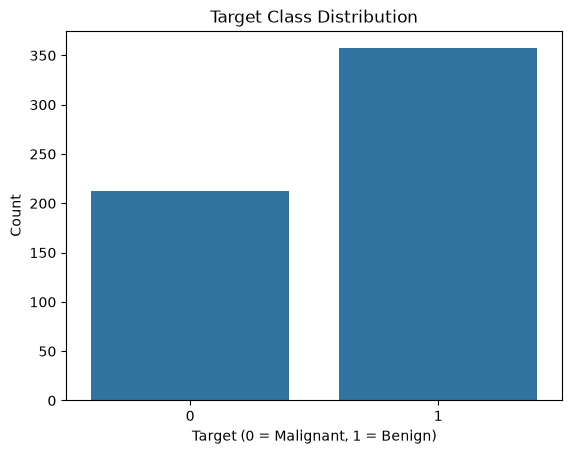

In [6]:
sns.countplot(x="target", data=df)

plt.title("Target Class Distribution")
plt.xlabel("Target (0 = Malignant, 1 = Benign)")
plt.ylabel("Count")
plt.show()

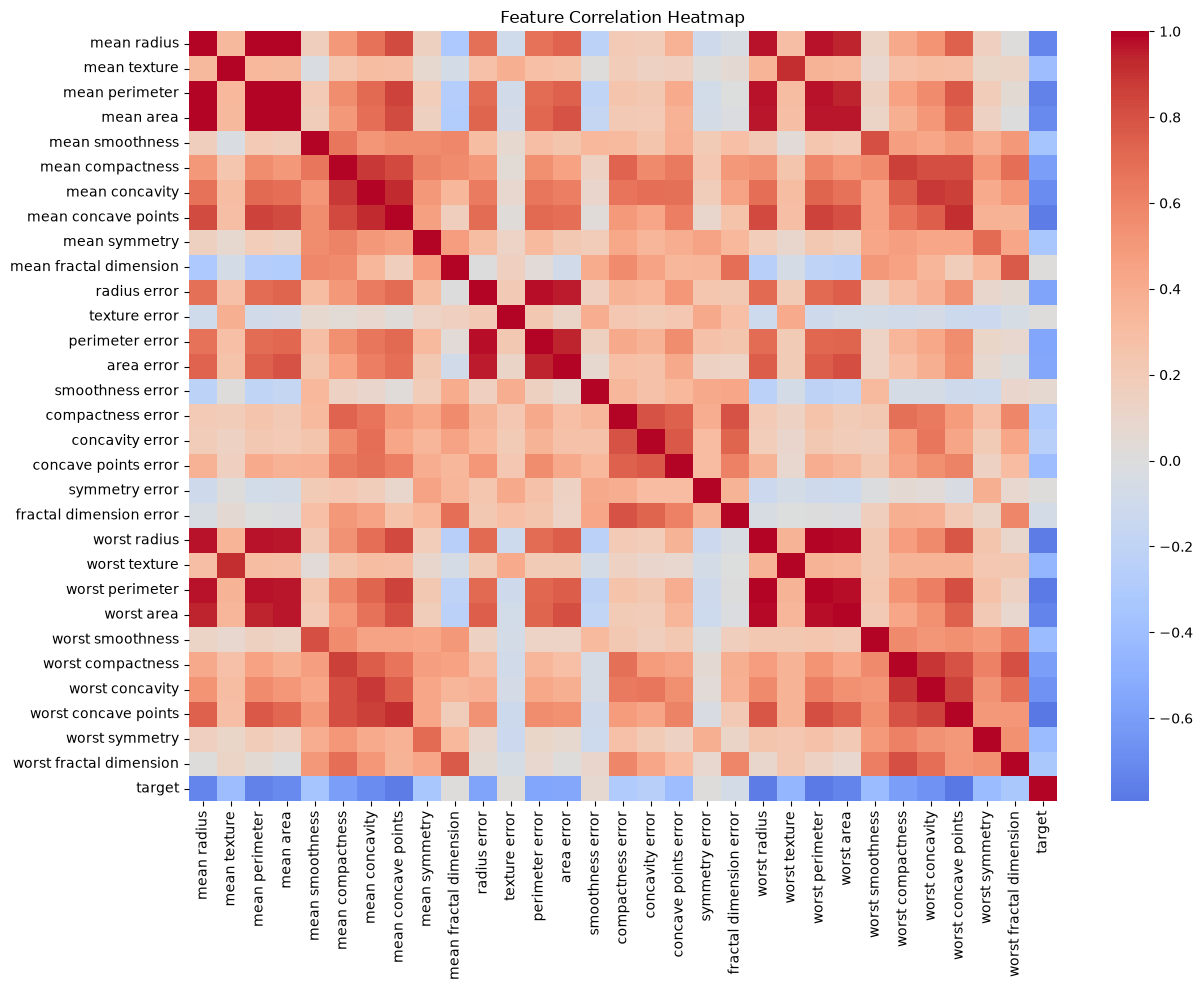

In [7]:
plt.figure(figsize=(14, 10))

sns.heatmap(
    df.corr(),
    cmap="coolwarm",
    center=0
)

plt.title("Feature Correlation Heatmap")
plt.show()

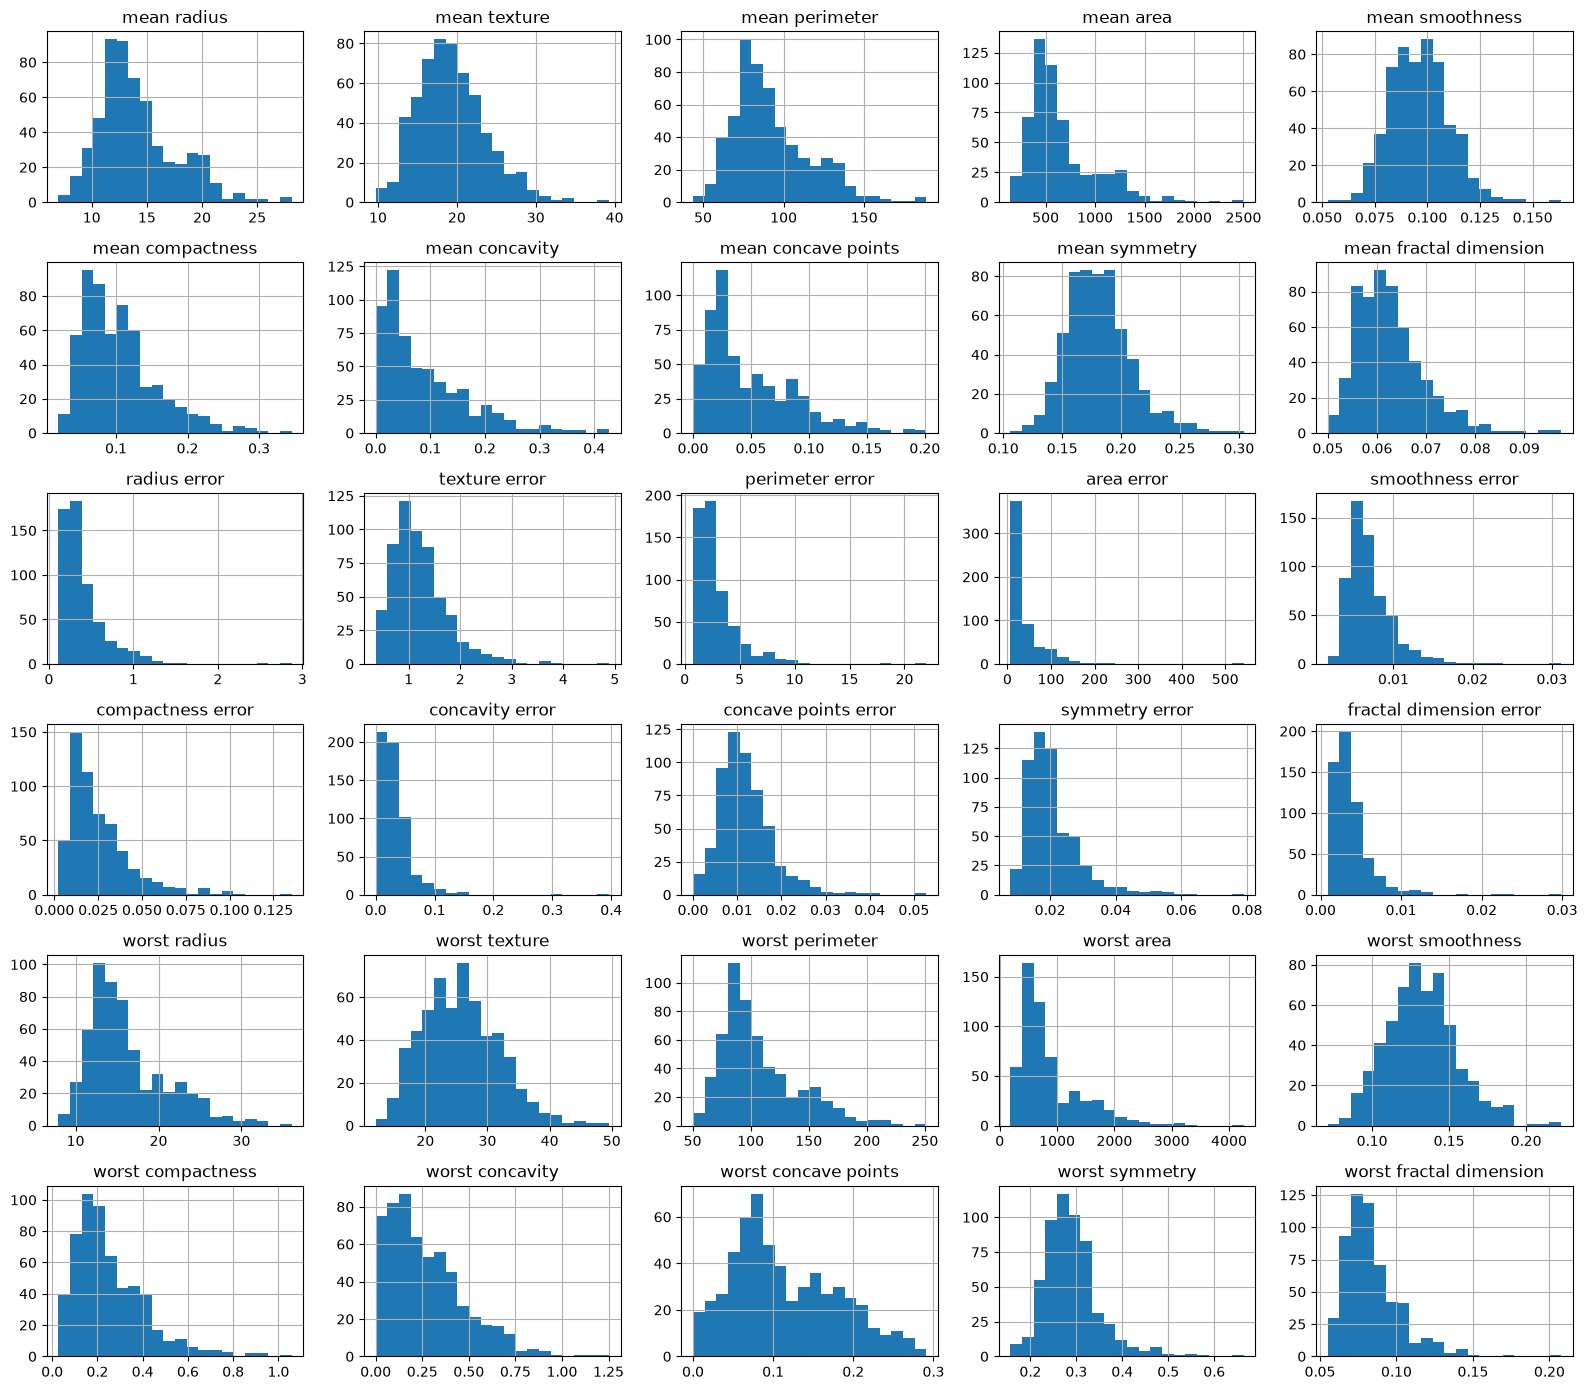

In [8]:
df.drop("target", axis=1).hist(
    figsize=(16, 14),
    bins=20
)

plt.tight_layout()
plt.show()

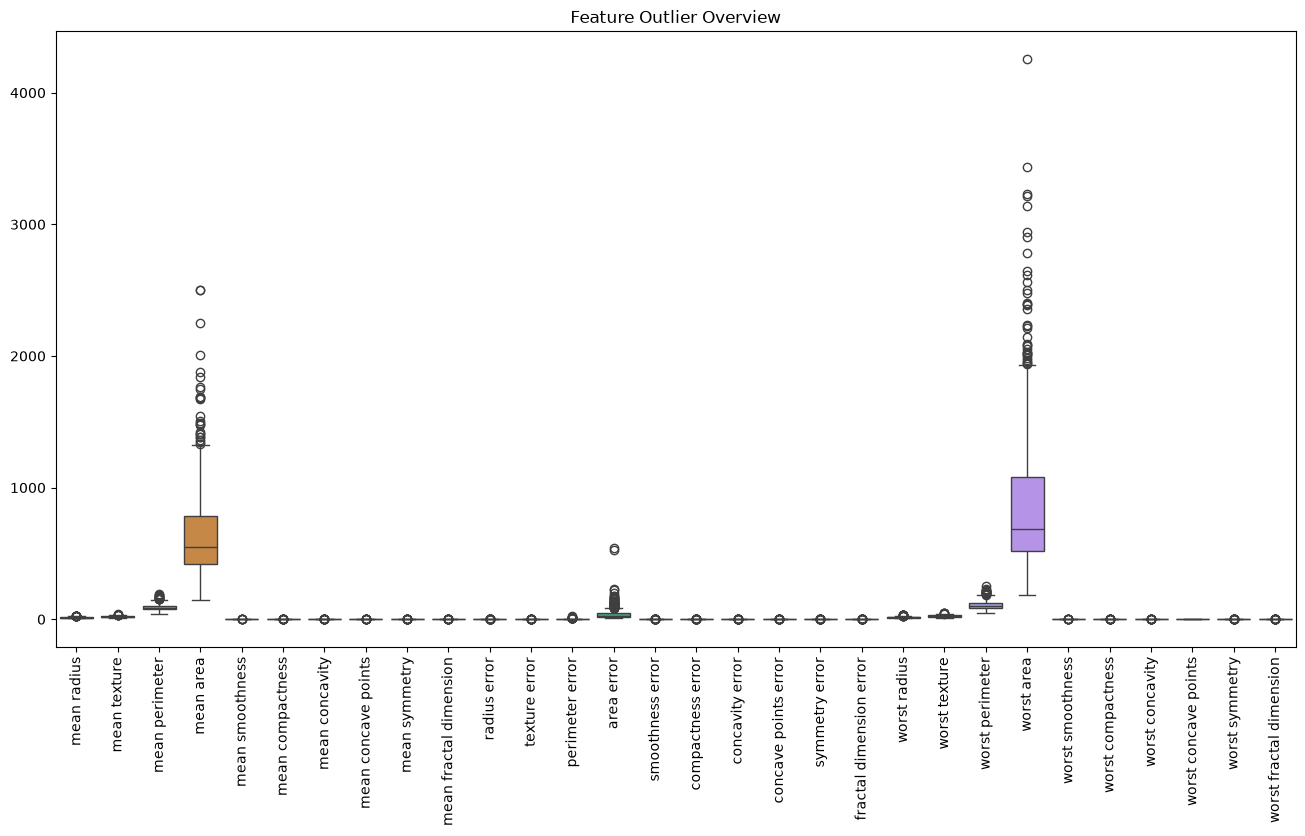

In [9]:
plt.figure(figsize=(16, 8))

sns.boxplot(data=df.drop("target", axis=1))

plt.xticks(rotation=90)
plt.title("Feature Outlier Overview")
plt.show()

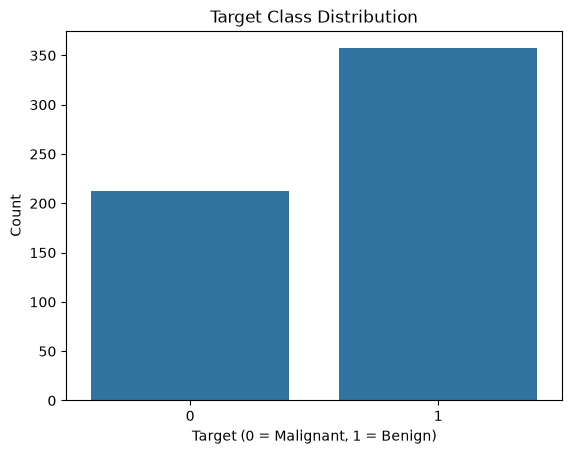

In [11]:
# sns.countplot(...)
sns.countplot(x="target", data=df)

plt.title("Target Class Distribution")
plt.xlabel("Target (0 = Malignant, 1 = Benign)")
plt.ylabel("Count")
plt.show()

## 4. Data Cleaning & Preprocessing

The dataset is already clean, with numerical features and no missing values.

We will:
- Verify missing values and duplicates
- Separate features (X) and target (y)
- Split data into training and testing sets
- Scale features where required
- Use Pipelines to prevent data leakage

In [12]:
from sklearn.model_selection import train_test_split

# Remove duplicate rows
df = df.drop_duplicates()

# Features and target
X = df.drop("target", axis=1)
y = df["target"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X shape:", X.shape)
print("Training set:", X_train.shape)
print("Test set:", X_test.shape)
print("Missing values:", X.isnull().sum().sum())

X shape: (569, 30)
Training set: (455, 30)
Test set: (114, 30)
Missing values: 0


## 5. Feature Selection

We will identify the most informative features and later compare models using:

- All features
- Selected features

This helps us understand whether reducing the number of features improves model performance.

In [13]:
from sklearn.feature_selection import SelectKBest, f_classif

# Select top 10 features
selector = SelectKBest(score_func=f_classif, k=10)

X_train_selected = selector.fit_transform(X_train, y_train)
X_test_selected = selector.transform(X_test)

selected_features = X_train.columns[selector.get_support()]

print("Selected Features:")
print(selected_features.tolist())

print("\nOriginal features:", X_train.shape[1])
print("Selected features:", X_train_selected.shape[1])

Selected Features:
['mean radius', 'mean perimeter', 'mean area', 'mean concavity', 'mean concave points', 'worst radius', 'worst perimeter', 'worst area', 'worst concavity', 'worst concave points']

Original features: 30
Selected features: 10


## 6. Pipelines & Baseline Models

We will build multiple classification models using Scikit-learn Pipelines.

Scaling is important for Logistic Regression, KNN, SVM, and Naive Bayes.

We will compare:

- Logistic Regression
- KNN
- Naive Bayes
- SVM
- Decision Tree
- Random Forest
- Gradient Boosting

In [14]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

models = {
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=5000))
    ]),

    "KNN": Pipeline([
        ("scaler", StandardScaler()),
        ("model", KNeighborsClassifier())
    ]),

    "Naive Bayes": Pipeline([
        ("scaler", StandardScaler()),
        ("model", GaussianNB())
    ]),

    "SVM": Pipeline([
        ("scaler", StandardScaler()),
        ("model", SVC(probability=True))
    ]),

    "Decision Tree": DecisionTreeClassifier(random_state=42),

    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        random_state=42
    ),

    "Gradient Boosting": GradientBoostingClassifier(random_state=42)
}

results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, predictions),
        "Precision": precision_score(y_test, predictions),
        "Recall": recall_score(y_test, predictions),
        "F1": f1_score(y_test, predictions)
    })

results_df = pd.DataFrame(results).sort_values("F1", ascending=False)

results_df

/Users/waleedkhokhar/Library/Python/3.14/lib/python/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


,Model,Accuracy,Precision,Recall,F1
0,Logistic Regression,0.982456,0.986111,0.986111,0.986111
3,SVM,0.982456,0.986111,0.986111,0.986111
6,Gradient Boosting,0.956140,0.946667,0.986111,0.965986
5,Random Forest,0.956140,0.958904,0.972222,0.965517
1,KNN,0.956140,0.958904,0.972222,0.965517
2,Naive Bayes,0.929825,0.944444,0.944444,0.944444
4,Decision Tree,0.912281,0.955882,0.902778,0.928571


## 7. Cross-Validation & Hyperparameter Tuning

We will use Cross-Validation to get a more reliable estimate of model performance.

Then GridSearchCV will test different hyperparameters and select the best configuration.

In [15]:
from sklearn.model_selection import cross_val_score, GridSearchCV

# Cross-validation for all models
cv_results = []

for name, model in models.items():
    scores = cross_val_score(model, X_train, y_train, cv=5, scoring="f1")
    
    cv_results.append({
        "Model": name,
        "Mean CV F1": scores.mean(),
        "Std CV F1": scores.std()
    })

cv_df = pd.DataFrame(cv_results).sort_values("Mean CV F1", ascending=False)

print("Cross-Validation Results:")
cv_df

/Users/waleedkhokhar/Library/Python/3.14/lib/python/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/Users/waleedkhokhar/Library/Python/3.14/lib/python/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/Users/waleedkhokhar/Library/Python/3.14/lib/python/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/Users/waleedkhokhar/Library/Python/3.14/lib/python/site-packages/sklearn/svm/_base.py:239: FutureWarning:

Cross-Validation Results:


,Model,Mean CV F1,Std CV F1
0,Logistic Regression,0.984344,0.010069
3,SVM,0.977292,0.014038
1,KNN,0.973999,0.016362
5,Random Forest,0.968444,0.015105
6,Gradient Boosting,0.965030,0.010638
2,Naive Bayes,0.945862,0.003969
4,Decision Tree,0.928176,0.014981


In [16]:
param_grids = {
    "Logistic Regression": {
        "model__C": [0.01, 0.1, 1, 10, 100]
    },
    "SVM": {
        "model__C": [0.1, 1, 10],
        "model__gamma": ["scale", "auto"],
        "model__kernel": ["rbf", "linear"]
    },
    "Random Forest": {
        "n_estimators": [100, 200],
        "max_depth": [None, 5, 10, 15],
        "min_samples_split": [2, 5]
    }
}

tuned_models = {}

for name, params in param_grids.items():
    grid = GridSearchCV(
        models[name],
        params,
        cv=5,
        scoring="f1",
        n_jobs=-1
    )
    
    grid.fit(X_train, y_train)
    tuned_models[name] = grid
    
    print(f"\n{name}")
    print("Best Params:", grid.best_params_)
    print("Best CV F1:", grid.best_score_)


Logistic Regression
Best Params: {'model__C': 0.1}
Best CV F1: 0.984524686809138


/Users/waleedkhokhar/Library/Python/3.14/lib/python/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/Users/waleedkhokhar/Library/Python/3.14/lib/python/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/Users/waleedkhokhar/Library/Python/3.14/lib/python/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/Users/waleedkhokhar/Library/Python/3.14/lib/python/site-packages/sklearn/svm/_base.py:239: FutureWarning:


SVM
Best Params: {'model__C': 0.1, 'model__gamma': 'scale', 'model__kernel': 'linear'}
Best CV F1: 0.9827547753047131

Random Forest
Best Params: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}
Best CV F1: 0.9684436877471334


## 🏆 Current Model Performance

Based on Cross-Validation and Hyperparameter Tuning:

### Best Models

**1. Logistic Regression**
- Mean CV F1: **98.43%**
- Std CV F1: **1.01%**
- Best overall performance so far
- Very stable across folds

**2. Support Vector Machine (SVM)**
- Mean CV F1: **97.73%**
- Tuned CV F1: **98.28%**
- Strong second-best model

**3. Random Forest**
- Mean CV F1: **96.84%**
- Good performance, but currently below Logistic Regression and SVM

### 📌 Current Conclusion

**Logistic Regression is currently the leading model**, while **SVM is a very strong alternative**.

We will not select the final model yet. We will continue with PCA, learning curves, ROC-AUC, confusion matrix, feature importance, and final evaluation before making the final decision.

## 8. PCA & Learning Curves

PCA will test whether we can reduce 30 features into fewer dimensions while retaining useful information.

Learning curves will help us understand whether the model is overfitting or underfitting.

In [17]:
from sklearn.decomposition import PCA
from sklearn.model_selection import learning_curve
import numpy as np
import matplotlib.pyplot as plt

# PCA experiment
pca = PCA(n_components=0.95)

X_train_scaled = StandardScaler().fit_transform(X_train)

X_train_pca = pca.fit_transform(X_train_scaled)

print("Original features:", X_train.shape[1])
print("PCA components:", X_train_pca.shape[1])
print("Explained variance:", pca.explained_variance_ratio_.sum())

# Learning curve for Logistic Regression
log_model = models["Logistic Regression"]

train_sizes, train_scores, val_scores = learning_curve(
    log_model,
    X_train,
    y_train,
    cv=5,
    scoring="f1",
    train_sizes=np.linspace(0.1, 1.0, 5),
    n_jobs=-1
)

print("\nLearning Curve:")
print("Training F1:", train_scores.mean(axis=1))
print("Validation F1:", val_scores.mean(axis=1))

Original features: 30
PCA components: 10
Explained variance: 0.9526768937417549

Learning Curve:
Training F1: [0.98367347 0.98641169 0.98895682 0.99003073 0.99171159]
Validation F1: [0.96571422 0.98272864 0.98095559 0.98260471 0.98434384]


## 📊 PCA & Learning Curve Results

### PCA Results

- Original features: **30**
- PCA components: **10**
- Explained variance: **95.27%**

PCA reduced the feature space from 30 to 10 components while retaining approximately 95% of the information.

### Learning Curve Results

The Logistic Regression learning curve shows:

- Training F1 increases to approximately **99.17%**
- Validation F1 reaches approximately **98.43%**
- Training and validation scores remain close to each other

### 📌 Interpretation

The model does not show significant overfitting. Its validation performance remains consistently high as more training data is used.

PCA successfully provides dimensionality reduction, but we will later compare the PCA model with the original model before deciding whether PCA should be used in the final pipeline.

## 9. Validation Curve

A validation curve shows how model performance changes when we vary one hyperparameter.

We will use the **SVM C parameter** because SVM is one of our strongest models.

This helps us understand:

- Underfitting
- Overfitting
- The effect of hyperparameters
- Where the model performs best

In [19]:
import pandas as pd
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split

data = load_breast_cancer()

df = pd.DataFrame(data.data, columns=data.feature_names)
df["target"] = data.target

X = df.drop("target", axis=1)
y = df["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

X_train: (455, 30)
X_test: (114, 30)


# SVM pipeline

In [20]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

svm_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", SVC(probability=True))
])

In [21]:
models = {
    "Logistic Regression": ...,
    "KNN": ...,
    "Naive Bayes": ...,
    "SVM": ...,
    "Decision Tree": ...,
    "Random Forest": ...,
    "Gradient Boosting": ...
}

# Validation Curve

In [22]:
from sklearn.model_selection import validation_curve

param_range = [0.01, 0.1, 1, 10, 100]

train_scores, val_scores = validation_curve(
    svm_model,
    X_train,
    y_train,
    param_name="model__C",
    param_range=param_range,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

print("C values:", param_range)
print("Training F1:", train_scores.mean(axis=1))
print("Validation F1:", val_scores.mean(axis=1))

/Users/waleedkhokhar/Library/Python/3.14/lib/python/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/Users/waleedkhokhar/Library/Python/3.14/lib/python/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/Users/waleedkhokhar/Library/Python/3.14/lib/python/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/Users/waleedkhokhar/Library/Python/3.14/lib/python/site-packages/sklearn/svm/_base.py:239: FutureWarning:

C values: [0.01, 0.1, 1, 10, 100]
Training F1: [0.77027027 0.96487255 0.98867471 0.99476932 1.        ]
Validation F1: [0.77027027 0.95708157 0.97729232 0.97729031 0.96654698]


/Users/waleedkhokhar/Library/Python/3.14/lib/python/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/Users/waleedkhokhar/Library/Python/3.14/lib/python/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/Users/waleedkhokhar/Library/Python/3.14/lib/python/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


## 10. Final Model Evaluation

Logistic Regression has performed best during cross-validation.

We will now evaluate it on the unseen test set using:

- Accuracy
- Precision
- Recall
- F1-score
- Confusion Matrix
- Classification Report

In [24]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# Final Logistic Regression pipeline
final_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=5000))
])

# Train
final_model.fit(X_train, y_train)

# Predict
y_pred = final_model.predict(X_test)

# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred,
    target_names=["Malignant", "Benign"]
))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.9824561403508771
Precision: 0.9861111111111112
Recall: 0.9861111111111112
F1 Score: 0.9861111111111112

Classification Report:
              precision    recall  f1-score   support

   Malignant       0.98      0.98      0.98        42
      Benign       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114

Confusion Matrix:
[[41  1]
 [ 1 71]]


## 📊 Final Evaluation Results

Logistic Regression achieved excellent performance on the unseen test set:

- Accuracy: **98.25%**
- Precision: **98.61%**
- Recall: **98.61%**
- F1-score: **98.61%**

The confusion matrix shows only **2 misclassified samples out of 114**.

The model correctly classified:
- 41 malignant cases
- 71 benign cases

This indicates that Logistic Regression is currently the strongest candidate for our final model.

ROC-AUC: 0.9953703703703703


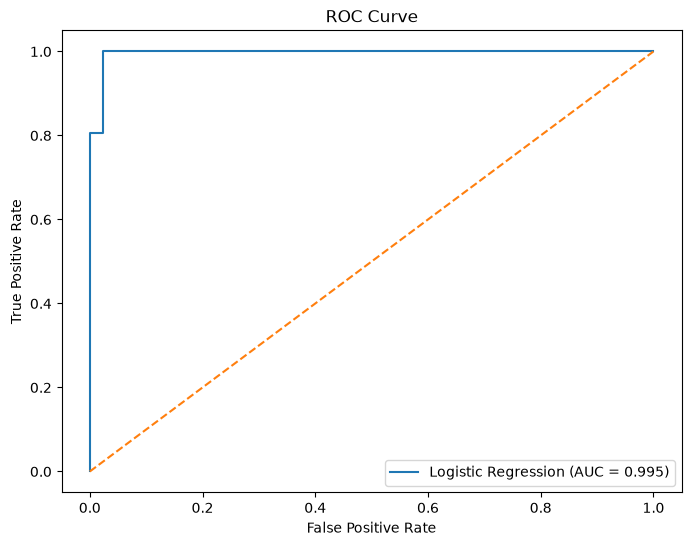

In [25]:
from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt

# Probability of Benign class (class 1)
y_proba = final_model.predict_proba(X_test)[:, 1]

# ROC-AUC
auc_score = roc_auc_score(y_test, y_proba)

print("ROC-AUC:", auc_score)

# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_proba)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"Logistic Regression (AUC = {auc_score:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [26]:

print("ROC-AUC:", auc_score)


ROC-AUC: 0.9953703703703703


In [27]:
print("FPR:", fpr)
print("TPR:", tpr)

FPR: [0.         0.         0.         0.02380952 0.02380952 1.        ]
TPR: [0.         0.01388889 0.80555556 0.80555556 1.         1.        ]


## 📈 ROC-AUC Evaluation

The Logistic Regression model achieved a ROC-AUC score of **99.54%**.

This indicates that the model has excellent ability to distinguish between malignant and benign tumors across different classification thresholds.

**ROC-AUC: 0.9954**

In [28]:
# Get Logistic Regression coefficients
coefficients = final_model.named_steps["model"].coef_[0]

feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Coefficient": coefficients
})

feature_importance["Absolute Importance"] = (
    feature_importance["Coefficient"].abs()
)

feature_importance = feature_importance.sort_values(
    "Absolute Importance",
    ascending=False
)

print(feature_importance.head(10))

                 Feature  Coefficient  Absolute Importance
21         worst texture    -1.255088             1.255088
10          radius error    -1.082965             1.082965
27  worst concave points    -0.953686             0.953686
23            worst area    -0.947756             0.947756
20          worst radius    -0.947616             0.947616
28        worst symmetry    -0.939181             0.939181
13            area error    -0.929104             0.929104
26       worst concavity    -0.823151             0.823151
22       worst perimeter    -0.763220             0.763220
24      worst smoothness    -0.746625             0.746625


## 🔍 Feature Importance

Logistic Regression coefficients were used to identify the most influential features.

The strongest features include:

- Worst texture
- Radius error
- Worst concave points
- Worst area
- Worst radius
- Worst symmetry
- Area error
- Worst concavity
- Worst perimeter
- Worst smoothness

The absolute value of the coefficient represents the strength of the feature's influence, while the sign represents its direction.

In [29]:
# Predict probabilities
probabilities = final_model.predict_proba(X_test)

print("First 10 probability predictions:")
print(probabilities[:10])

print("\nFirst 10 predicted classes:")
print(y_pred[:10])

First 10 probability predictions:
[[9.99999941e-01 5.88824186e-08]
 [1.13351672e-05 9.99988665e-01]
 [9.93589175e-01 6.41082462e-03]
 [4.66491463e-01 5.33508537e-01]
 [9.99999999e-01 6.52500097e-10]
 [7.83960163e-03 9.92160398e-01]
 [1.71746799e-05 9.99982825e-01]
 [9.99999436e-01 5.63527494e-07]
 [9.99945684e-01 5.43163692e-05]
 [1.00000000e+00 8.04184941e-11]]

First 10 predicted classes:
[0 1 0 1 0 1 1 0 0 0]


In [31]:
# Predict probabilities
probabilities = final_model.predict_proba(X_test)

print("First 10 probability predictions:")
print(probabilities[:10])

print("\nFirst 10 predicted classes:")
print(y_pred[:10])

First 10 probability predictions:
[[9.99999941e-01 5.88824186e-08]
 [1.13351672e-05 9.99988665e-01]
 [9.93589175e-01 6.41082462e-03]
 [4.66491463e-01 5.33508537e-01]
 [9.99999999e-01 6.52500097e-10]
 [7.83960163e-03 9.92160398e-01]
 [1.71746799e-05 9.99982825e-01]
 [9.99999436e-01 5.63527494e-07]
 [9.99945684e-01 5.43163692e-05]
 [1.00000000e+00 8.04184941e-11]]

First 10 predicted classes:
[0 1 0 1 0 1 1 0 0 0]


In [32]:
probabilities = final_model.predict_proba(X_test)

print("First 10 probability predictions:")
print(probabilities[:10])

print("\nFirst 10 predicted classes:")
print(y_pred[:10])

First 10 probability predictions:
[[9.99999941e-01 5.88824186e-08]
 [1.13351672e-05 9.99988665e-01]
 [9.93589175e-01 6.41082462e-03]
 [4.66491463e-01 5.33508537e-01]
 [9.99999999e-01 6.52500097e-10]
 [7.83960163e-03 9.92160398e-01]
 [1.71746799e-05 9.99982825e-01]
 [9.99999436e-01 5.63527494e-07]
 [9.99945684e-01 5.43163692e-05]
 [1.00000000e+00 8.04184941e-11]]

First 10 predicted classes:
[0 1 0 1 0 1 1 0 0 0]


## 🎯 Probability Prediction

Instead of only predicting Malignant or Benign, the model can also provide the probability of each class.

For each sample:

- Column 1 = Malignant probability
- Column 2 = Benign probability
- The class with the higher probability becomes the prediction

This provides more information than a simple binary prediction.

In [33]:
import joblib

# Save the complete pipeline
joblib.dump(final_model, "breast_cancer_model.pkl")

print("Model saved successfully!")

Model saved successfully!


## 🔮 Final Prediction Function

We will create a reusable prediction function using the saved Machine Learning pipeline.

The function will return:
- Predicted class
- Malignant probability
- Benign probability

Because the complete preprocessing pipeline was saved, new data will automatically be scaled before prediction.

In [34]:
def predict_tumor(features):
    """
    Predict whether a tumor is malignant or benign.

    Parameters:
        features: list or array containing the 30 feature values

    Returns:
        Prediction and class probabilities
    """

    prediction = loaded_model.predict([features])[0]
    probabilities = loaded_model.predict_proba([features])[0]

    result = {
        "Prediction": "Benign" if prediction == 1 else "Malignant",
        "Malignant Probability": probabilities[0],
        "Benign Probability": probabilities[1]
    }

    return result

In [35]:
loaded_model = joblib.load("breast_cancer_model.pkl")

print("Model loaded successfully!")

Model loaded successfully!


In [36]:
# Take one sample from the test set
sample = X_test.iloc[[0]]

# Make prediction
result = predict_tumor(sample.iloc[0].values)

print(result)

{'Prediction': 'Malignant', 'Malignant Probability': np.float64(0.9999999411175814), 'Benign Probability': np.float64(5.888241860705877e-08)}


/Users/waleedkhokhar/Library/Python/3.14/lib/python/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/Users/waleedkhokhar/Library/Python/3.14/lib/python/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [37]:
loaded_model = joblib.load("breast_cancer_model.pkl")

print("Model loaded successfully!")

Model loaded successfully!


# 🏁 Final Project Results

## Model Performance

| Metric | Result |
|---|---:|
| Accuracy | **98.25%** |
| Precision | **98.61%** |
| Recall | **98.61%** |
| F1-score | **98.61%** |
| ROC-AUC | **99.54%** |

## Final Model

**Logistic Regression + StandardScaler Pipeline**

### Key Findings

- Logistic Regression achieved the best mean CV F1-score: **98.43%**
- Test F1-score: **98.61%**
- ROC-AUC: **99.54%**
- Only **2 errors out of 114** test samples
- PCA reduced **30 features → 10 components** while retaining **95.27% variance**
- Learning and validation curves showed strong generalization
- Feature selection identified the most informative features
- Multiple classification algorithms were compared
- Hyperparameters were optimized using GridSearchCV
- The complete ML pipeline was saved and loaded using Joblib
- A reusable prediction function was created for future API/deployment use

## Conclusion

Logistic Regression was the strongest model for this dataset based on cross-validation and test performance.

The complete workflow demonstrates an end-to-end Machine Learning classification project, from EDA and preprocessing to model evaluation, tuning, probability prediction, and model deployment preparation.

> **Note:** This project is for Machine Learning education and demonstration. It is not a clinically validated medical diagnostic system.